# WT EFA — supplementary figure

Two signal components, extracted I(q), conventional and extended Guinier fits. [PDF](WT_EFA_SI.pdf) · [SVG](WT_EFA_SI.svg)

{
  "Monomer / main peak": {
    "conventional": {
      "Rg": 24.871446655158135,
      "I0": 1.81305353188651,
      "Rg_conditional_se": 0.6284632036098071,
      "qmin": 0.012,
      "qmax": 0.043,
      "qRgmax": 1.0694722061717996,
      "chi2_reduced": 0.23125648120703032,
      "n": 32,
      "bootstrap95": [
        24.02653442443529,
        25.787293769789358
      ],
      "bootstrap_valid": 200,
      "bootstrap_mean_Rg": 24.90661770801702,
      "bootstrap_sd_Rg": 0.4420202443246371
    },
    "extended": {
      "Rg": 25.188759805778652,
      "nu": 0.49483031564321717,
      "I0": 1.804236231351429,
      "Rg_conditional_se": 0.20224710105832427,
      "chi2_reduced": 0.3812667287882627,
      "qmin": 0.012,
      "qmax": 0.07800000000000003,
      "qRgmax": 1.9647232648507356,
      "n": 53,
      "residues": 120,
      "boundary": false,
      "bootstrap95": [
        24.831089148949786,
        25.610729285401096
      ],
      "bootstrap_valid": 200,
      "bootstra

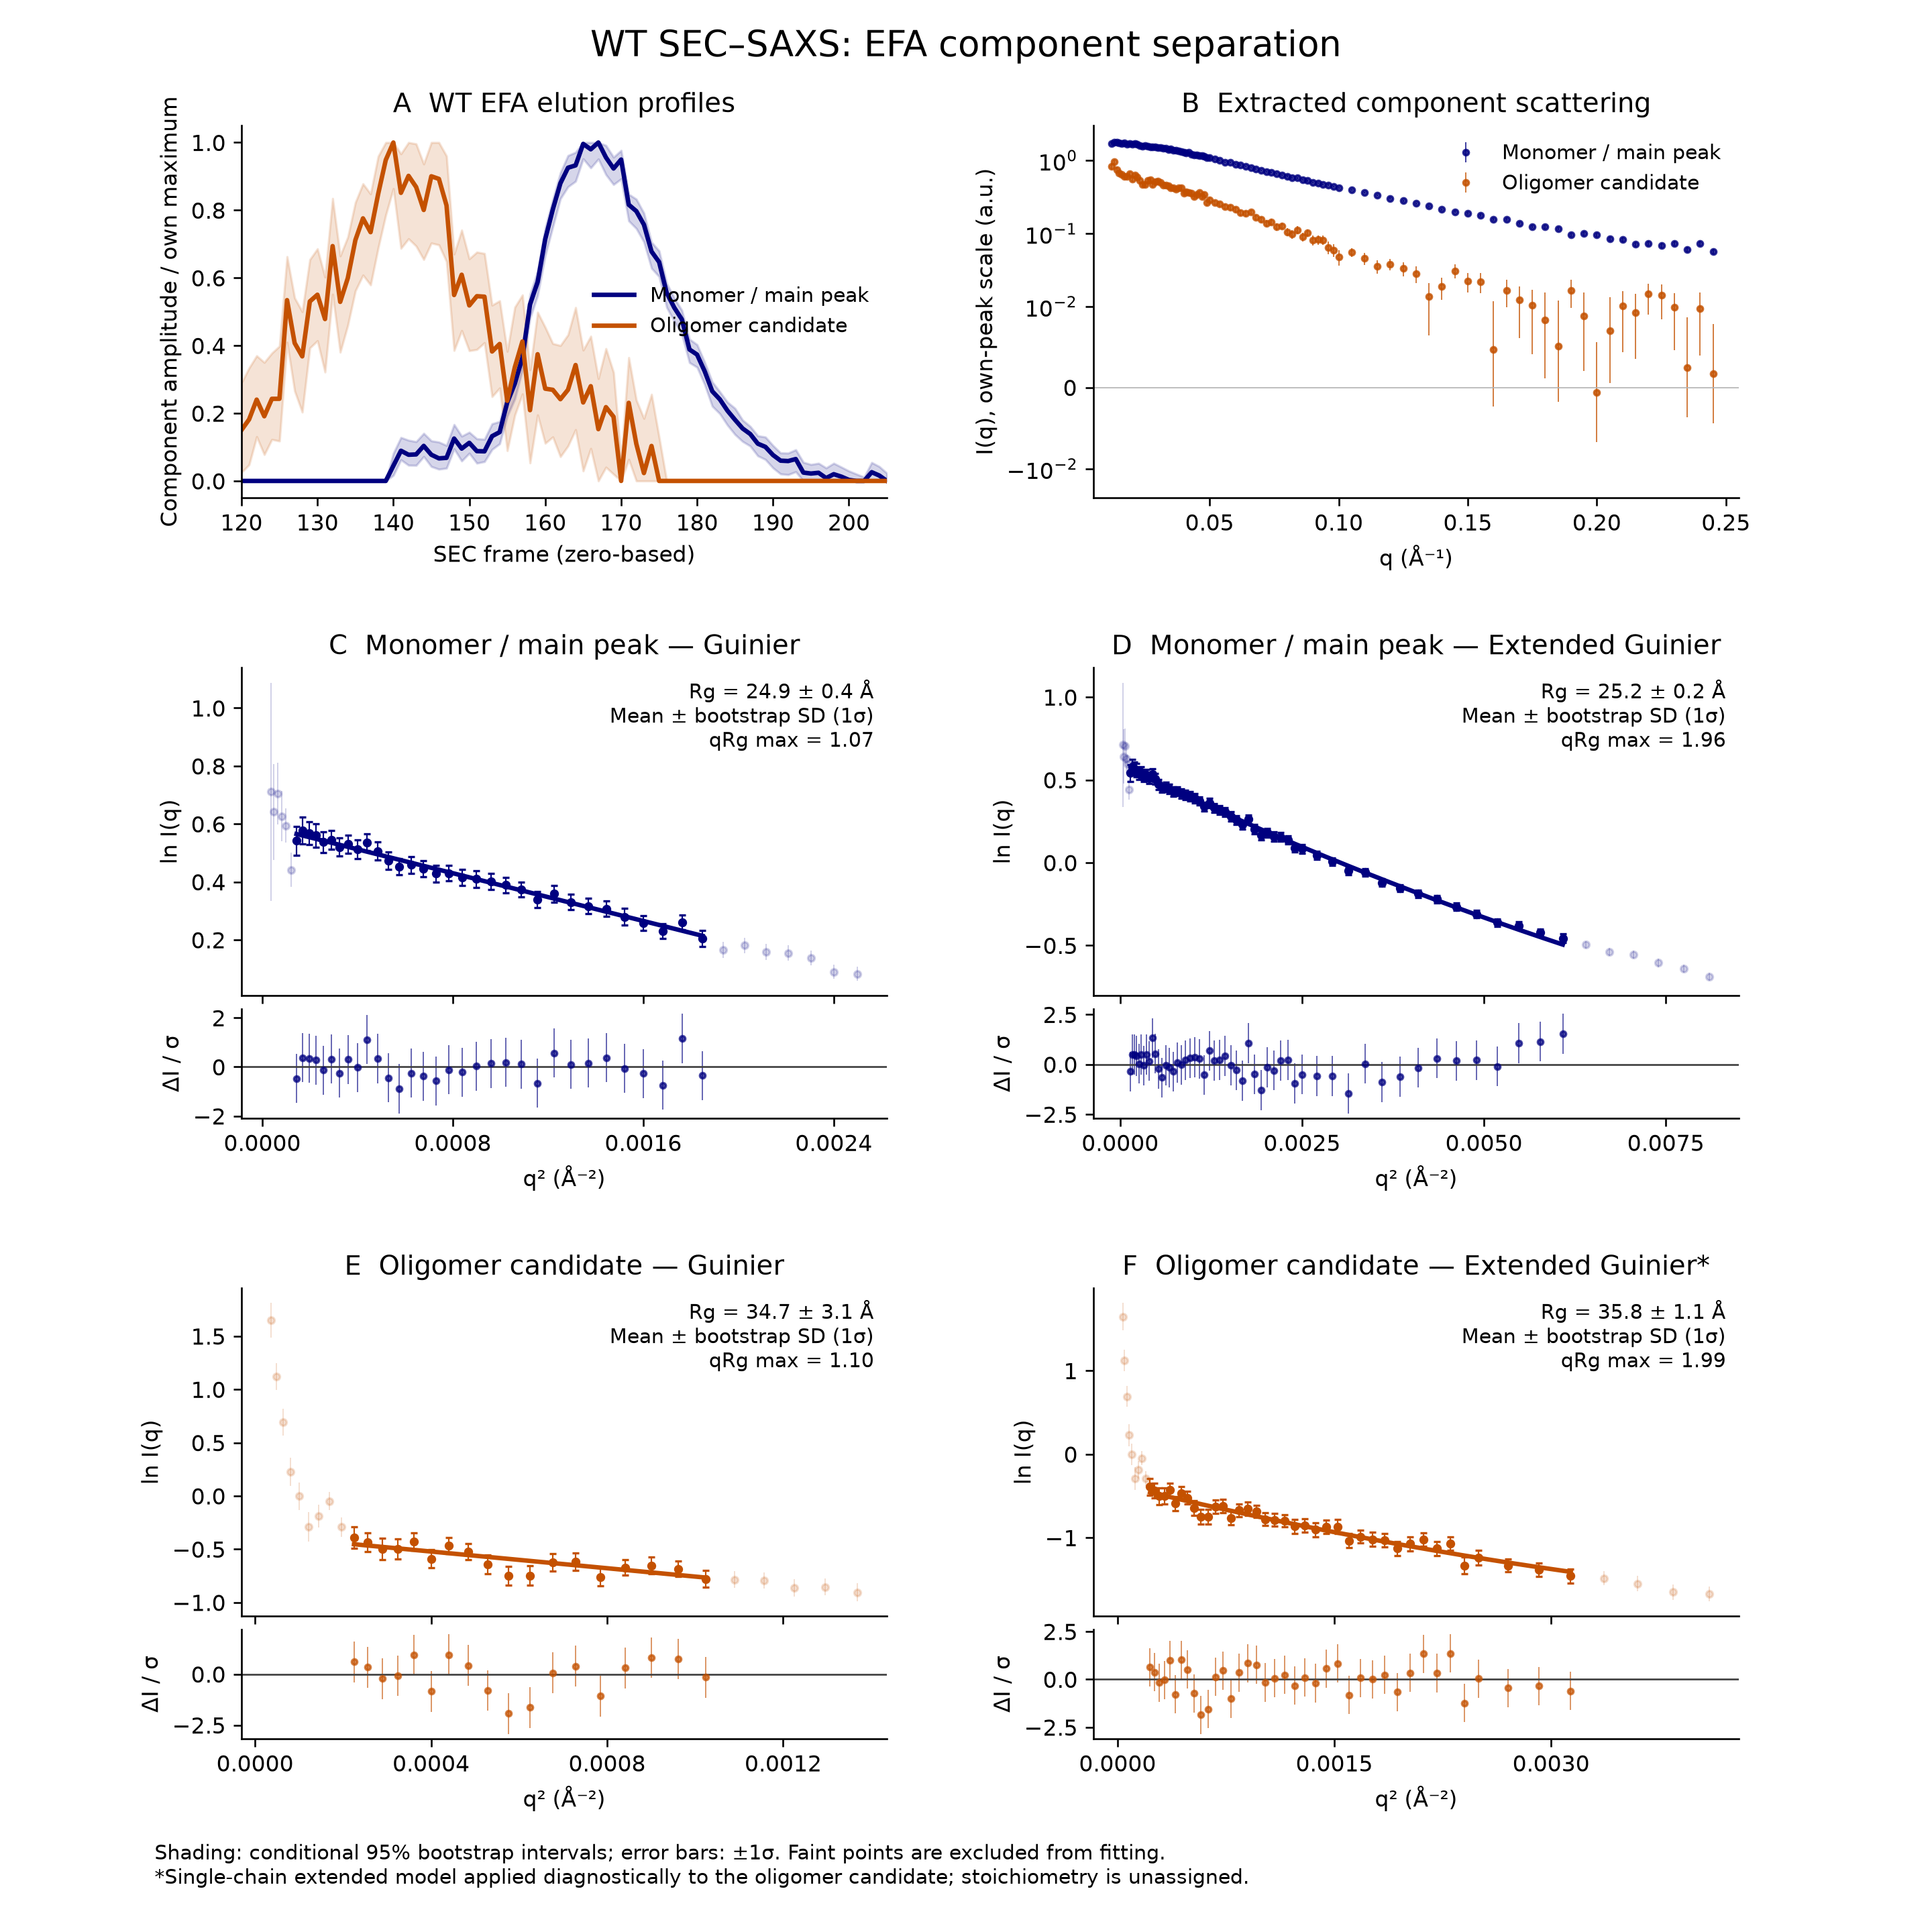

In [1]:
from pathlib import Path
from IPython.display import Image,display,Markdown
import json
exec(compile(Path('make_figure.py').read_text(), 'make_figure.py', 'exec'), {'__file__':str(Path('make_figure.py').resolve())})
display(Image(filename='WT_EFA_SI.png'))

**Figure S: WT SEC–SAXS component separation.** (A) EFA-guided rank-two rotation resolves the main peak and early-eluting oligomer candidate. The component amplitudes are independently normalized to their maxima; shaded bands are conditional 95% intervals from 200 parametric bootstrap repetitions. (B) Extracted scattering profiles at each component’s peak, with ±1σ errors from refitting the decomposition. Signed points are retained using a symmetric logarithmic intensity axis. (C–F) Conventional and extended Guinier fits, with intensity-space standardized residuals below each fit. Faint points were excluded from regression.

WT buffer frames 220–236 were subtracted from the analysis region 120–205 (zero-based, inclusive). Temporal supports were fixed at 120–175 and 140–205. Higher modes are left in the reconstruction residual and are not displayed as species; this is a rank-two model, not a rank-three fit with a hidden third component. No profile was smoothed.

Main-component fits start at q=0.012 Å⁻¹. Early-component fits start at 0.015 Å⁻¹ to exclude its low-q upturn; this choice is explicit and the qmin sensitivity is tabulated below. Each fit uses the widest eligible range satisfying qmax Rg≤1.1 for conventional or ≤2 for extended Guinier, with the existing minimum-point and signal screens. Figure Rg labels report the mean ± sample standard deviation (1σ) of the 200 bootstrap refits; the 95% percentile intervals are retained in the results table. Intervals refit each bootstrap profile at the selected fixed range, preserving q-correlations induced by buffer subtraction and decomposition. They exclude baseline/support/model uncertainty.

The extended model is Zheng & Best (2018), equations 5–6, with the supplied 120-residue sequence. Its application to the early component is diagnostic: a multichain oligomer is not a single chain of 120 residues. Neither this fit nor EFA assigns oligomer stoichiometry. “Monomer” denotes the main-peak working interpretation.

Compared with earlier exports, component intensities here are scaled to their own peak rather than their small contribution in the monomer averaging window. Uncertainties were recalculated after this normalization. Extended fits use the admissible range out to qRg≈2 rather than the earlier fixed qmax≈0.055 Å⁻¹; that accounts for the modest main-component Rg difference.

Reference: https://pmc.ncbi.nlm.nih.gov/articles/PMC6093220/

In [2]:
r=json.loads(Path('fit_results.json').read_text())
rows=['|Component|Fit|Mean ± SD (Å)|95% percentile interval (Å)|','|---|---|---:|---:|']
for name,entry in r.items():
    for method,f in entry.items():
        if 'bootstrap_mean_Rg' not in f: continue
        lo,hi=f['bootstrap95']
        rows.append(f"|{name}|{method}|{f['bootstrap_mean_Rg']:.2f} ± {f['bootstrap_sd_Rg']:.2f}|{lo:.2f}–{hi:.2f}|")
display(Markdown('\n'.join(rows)))

|Component|Fit|Mean ± SD (Å)|95% percentile interval (Å)|
|---|---|---:|---:|
|Monomer / main peak|conventional|24.91 ± 0.44|24.03–25.79|
|Monomer / main peak|extended|25.19 ± 0.21|24.83–25.61|
|Oligomer candidate|conventional|34.75 ± 3.05|27.83–40.16|
|Oligomer candidate|extended_single_chain_diagnostic|35.84 ± 1.14|33.80–37.93|

In [3]:
r=json.loads(Path('fit_results.json').read_text())
rows=['|Component|qmin (Å⁻¹)|Guinier Rg (Å)|Extended Rg (Å)|','|---|---:|---:|---:|']
for name,entry in r.items():
    for lo,rr in entry['qmin_sensitivity'].items():
        fmt=lambda f: 'not eligible' if f is None else f"{f['Rg']:.2f}"
        rows.append(f"|{name}|{lo}|{fmt(rr['guinier'])}|{fmt(rr['extended'])}|")
display(Markdown('\n'.join(rows)))

|Component|qmin (Å⁻¹)|Guinier Rg (Å)|Extended Rg (Å)|
|---|---:|---:|---:|
|Monomer / main peak|0.01|24.94|25.15|
|Monomer / main peak|0.012|24.87|25.19|
|Monomer / main peak|0.015|24.83|25.17|
|Monomer / main peak|0.02|24.99|25.00|
|Oligomer candidate|0.01|not eligible|37.73|
|Oligomer candidate|0.012|not eligible|37.16|
|Oligomer candidate|0.015|34.29|35.59|
|Oligomer candidate|0.02|30.65|34.86|

## Reproduction
`recover_components.py` reads the repository raw profiles, subtracts the shared buffer, reruns EFA rotation for 200 perturbations, and writes the component arrays and exported profiles. `make_figure.py` refits these saved bootstrap profiles. Set `SAXS_REPO` to the analysis repository path on another computer. The full bootstrap is retained in `WT_components.npz`.